In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=sns.load_dataset("diamonds")
df_c=df.copy()

In [3]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [5]:
df.shape

(53940, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [7]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [8]:
df.describe().T
# missing and categorical variables are not taken into account

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [9]:
df.isnull().values.any()
#if there is have null values
# df.isnull().sum()

False

In [10]:
# categorical variable analysis

In [11]:
cat_df=df.select_dtypes(include=["category"])
cat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   cut      53940 non-null  category
 1   color    53940 non-null  category
 2   clarity  53940 non-null  category
dtypes: category(3)
memory usage: 159.1 KB


In [12]:
for col in cat_df:
    print(f"{col} : {cat_df[col].cat.categories.tolist()}")

cut : ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
color : ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity : ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


In [13]:
print(cat_df["cut"].value_counts())

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64


In [14]:
print(cat_df["color"].value_counts())

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64


In [15]:
print(cat_df["clarity"].value_counts())

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [16]:
df.cut.cat.ordered

False

In [17]:
df.cut.cat.categories

Index(['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], dtype='object')

In [18]:
from pandas.api.types import CategoricalDtype
df.cut = pd.Categorical(df.cut, categories=["Fair", "Good", "Very Good", "Premium", "Ideal"], ordered=True)

In [19]:
df.cut.cat.categories

Index(['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], dtype='object')

In [20]:
df.clarity.cat.ordered

False

In [21]:
df.clarity.cat.categories

Index(['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'], dtype='object')

In [22]:
df.clarity = pd.Categorical(df.clarity, categories=['I1', 'SI2', 'SI1','VS2','VS1','VVS2','VVS1','IF'], ordered=True)
df.clarity.cat.categories

Index(['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'], dtype='object')

In [23]:
df.color.cat.ordered

False

In [24]:
df.color.cat.categories

Index(['D', 'E', 'F', 'G', 'H', 'I', 'J'], dtype='object')

In [25]:
df.color = pd.Categorical(df.color, categories=['J', 'I', 'H', 'G', 'F', 'E', 'D'], ordered=True)
df.color.cat.categories

Index(['J', 'I', 'H', 'G', 'F', 'E', 'D'], dtype='object')

In [26]:
# barplot

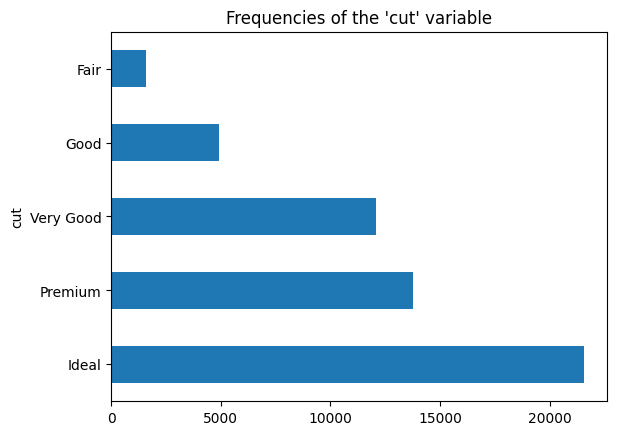

In [27]:
(df["cut"]
 .value_counts()
 .plot.barh()
 .set_title("Frequencies of the 'cut' variable"));

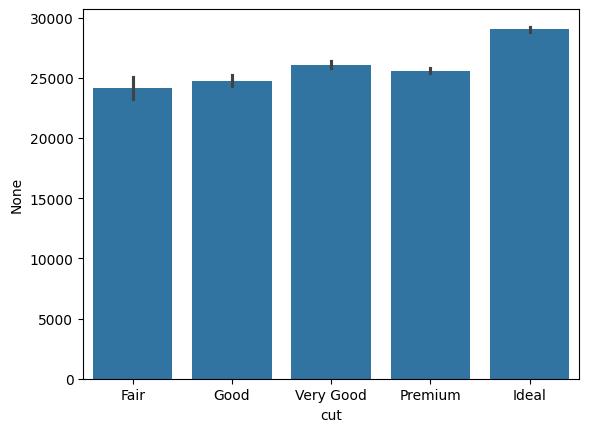

In [28]:
sns.barplot(x="cut", y=df.cut.index, data=df);

<ipython-input-29-1bd71a80b017>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cut", y="price", data=df, ax=axes[0], palette="Blues")
<ipython-input-29-1bd71a80b017>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="clarity", y="price", data=df, ax=axes[1], palette="Greens")
<ipython-input-29-1bd71a80b017>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="color", y="price", data=df, ax=axes[2], palette="Reds")


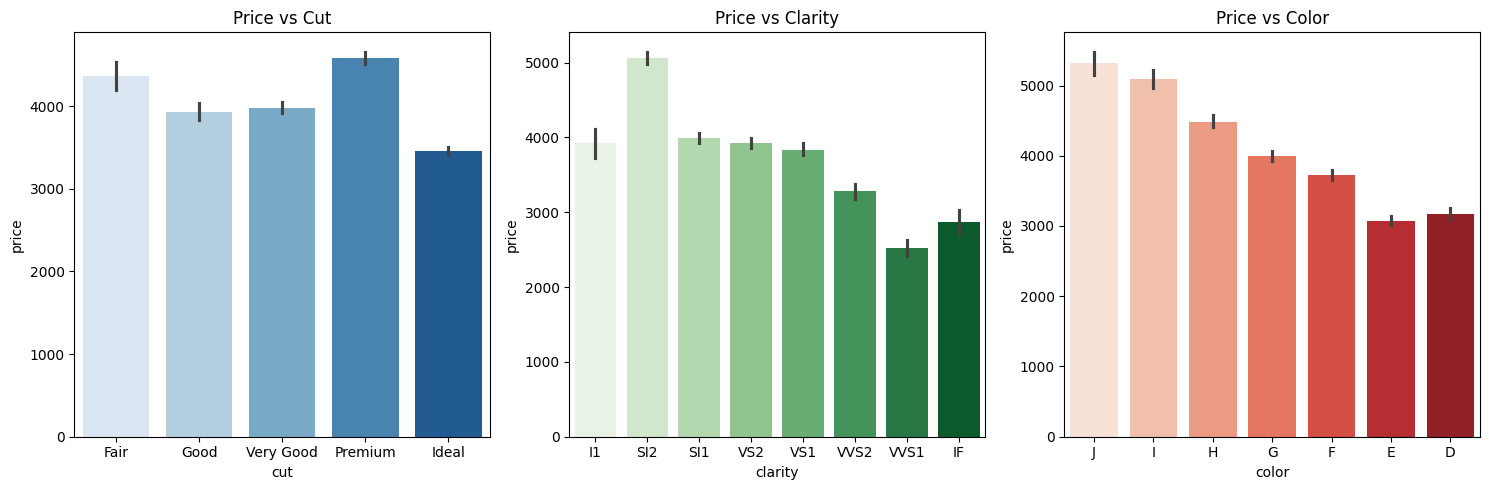

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(x="cut", y="price", data=df, ax=axes[0], palette="Blues")
axes[0].set_title("Price vs Cut")

sns.barplot(x="clarity", y="price", data=df, ax=axes[1], palette="Greens")
axes[1].set_title("Price vs Clarity")

sns.barplot(x="color", y="price", data=df, ax=axes[2], palette="Reds")
axes[2].set_title("Price vs Color")

plt.tight_layout();
plt.show();

<Axes: xlabel='cut', ylabel='price'>

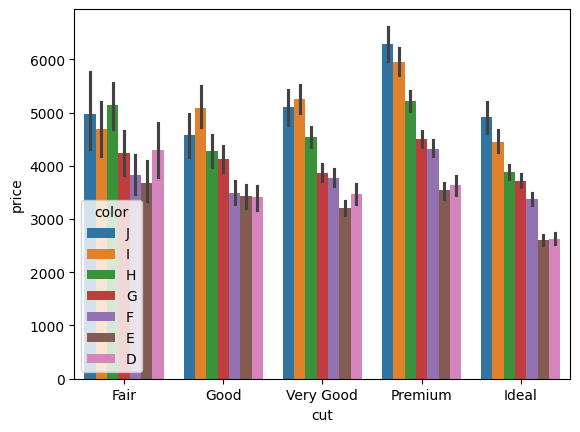

In [30]:
sns.barplot(x="cut", y="price", hue="color", data=df)

In [31]:
# for multidimensional barplot value analysis
df.groupby(["cut","color"])["price"].mean()

<ipython-input-31-49cf7d34085d>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cut","color"])["price"].mean()


cut        color
Fair       J        4975.655462
           I        4685.445714
           H        5135.683168
           G        4239.254777
           F        3827.003205
           E        3682.312500
           D        4291.061350
Good       J        4574.172638
           I        5078.532567
           H        4276.254986
           G        4123.482204
           F        3495.750275
           E        3423.644159
           D        3405.382175
Very Good  J        5103.513274
           I        5255.879568
           H        4535.390351
           G        3872.753806
           F        3778.820240
           E        3214.652083
           D        3470.467284
Premium    J        6294.591584
           I        5946.180672
           H        5216.706780
           G        4500.742134
           F        4324.890176
           E        3538.914420
           D        3631.292576
Ideal      J        4918.186384
           I        4451.970377
           H        3889.334831
           G        3720.706388
           F        3374.939362
           E        2597.550090
           D        2629.094566
Name: price, dtype: float64

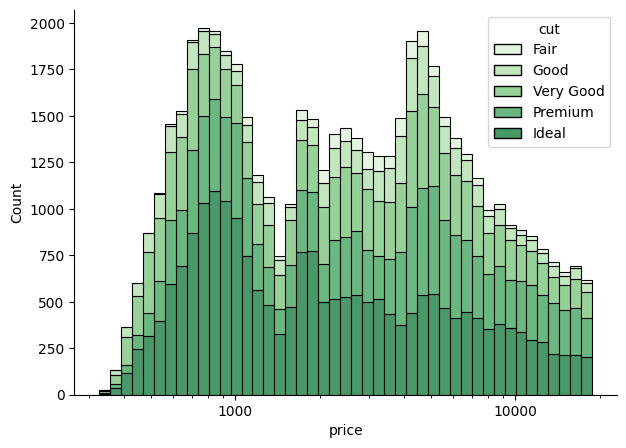

In [32]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    df,
    x="price", hue="cut",
    multiple="stack",
    palette="Greens",
    log_scale=True,
)
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())


In [33]:
# catplot

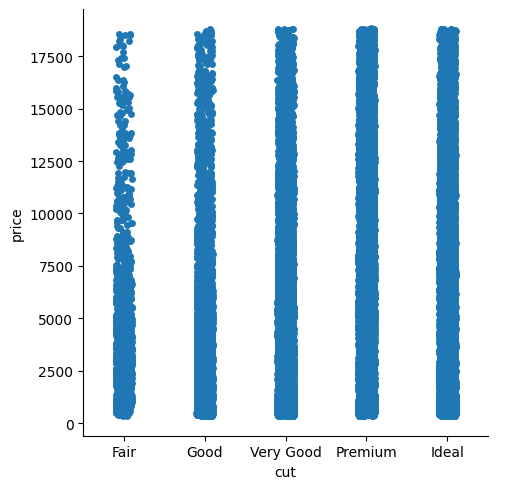

In [34]:
sns.catplot(x="cut", y="price",data=df)

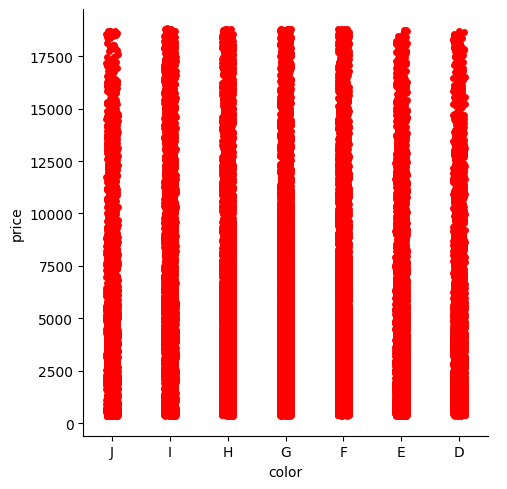

In [35]:
sns.catplot(x="color", y="price", data=df,color="red")

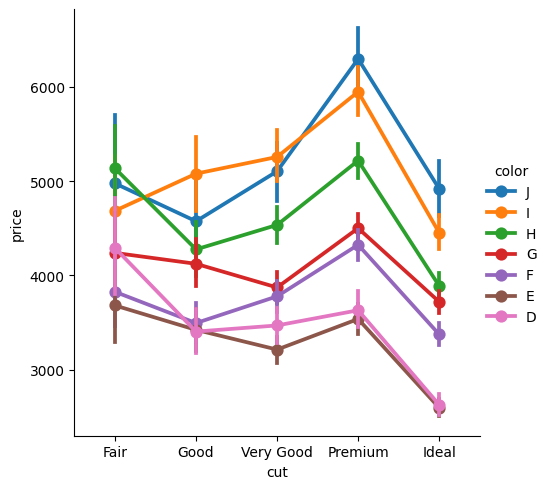

In [36]:
sns.catplot(x="cut",y="price",hue="color", kind="point",data=df)

In [37]:
#continuous variable analysis

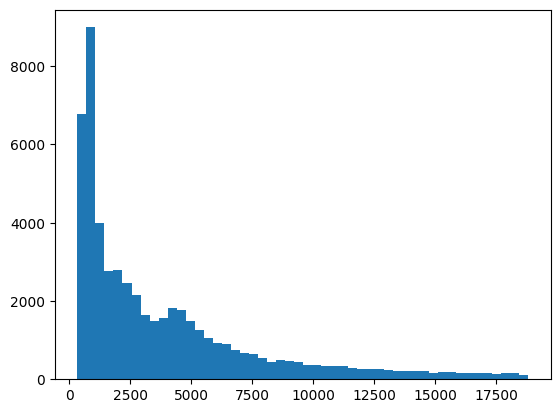

In [38]:
# histogram
plt.hist(df.price, bins=50);

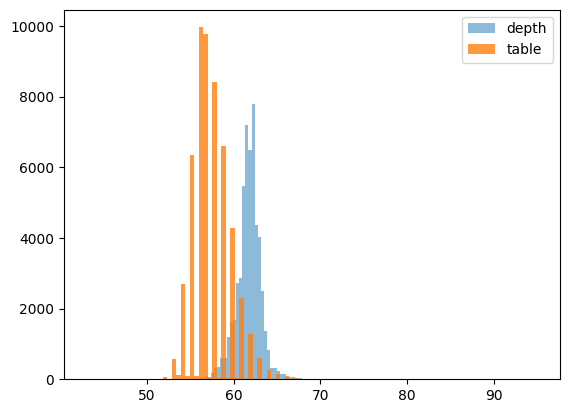

In [39]:
plt.hist(df.depth, alpha=0.5, bins=100)
plt.hist(df.table, alpha=0.8, bins=100)
plt.legend(["depth", "table"]);

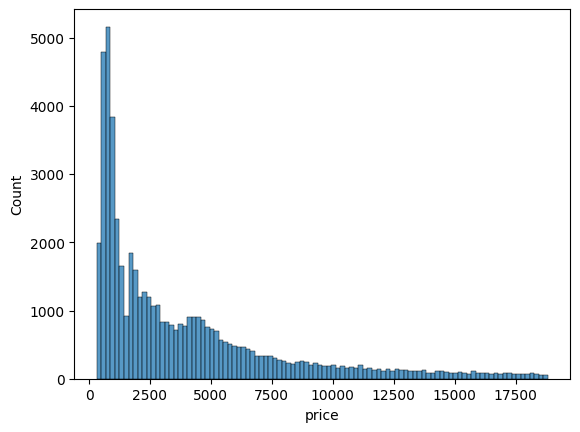

In [40]:
sns.histplot(df.price, bins=100);

<ipython-input-41-b1d7160b73fa>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.price);


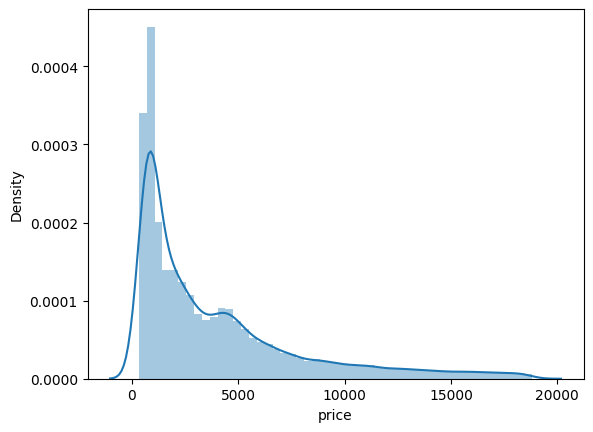

In [41]:
sns.distplot(df.price);

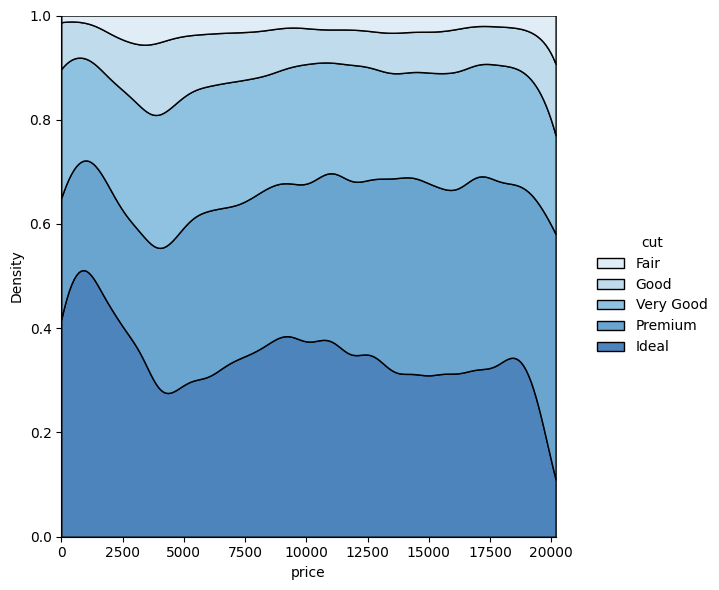

In [42]:
sns.displot(
    data=df,
    x="price", hue="cut",
    kind="kde", height=6,
    multiple="fill", clip=(0, None),
    palette="Blues",
)

<ipython-input-43-b303b3faf900>:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.price, shade=True);


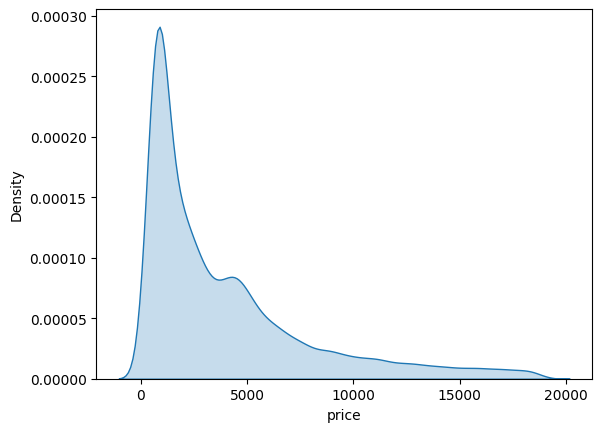

In [43]:
sns.kdeplot(df.price, shade=True);
# If there is more than one peak on the graph, it means that there is more than one factor affecting the target variable.

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_a

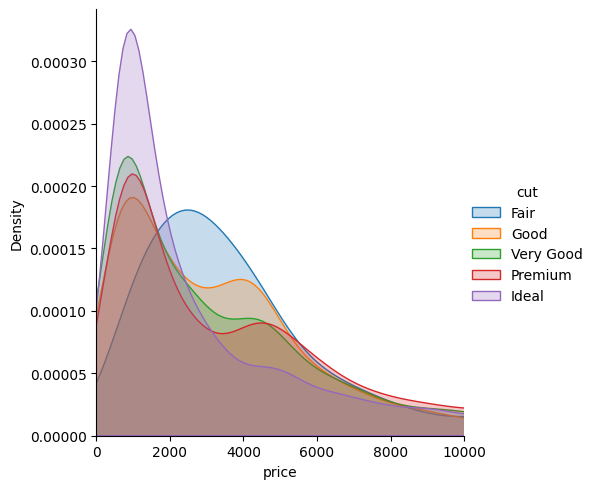

In [44]:
(sns.FacetGrid(df, hue ="cut", height =5, xlim=(0,10000))
.map(sns.kdeplot,"price",shade=True)
.add_legend()
);

<ipython-input-45-7ecc0f6b3828>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="price", hue="cut", shade=True, ax=axes[0])
<ipython-input-45-7ecc0f6b3828>:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="price", hue="clarity", shade=True, ax=axes[1])
<ipython-input-45-7ecc0f6b3828>:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="price", hue="color", shade=True, ax=axes[2])


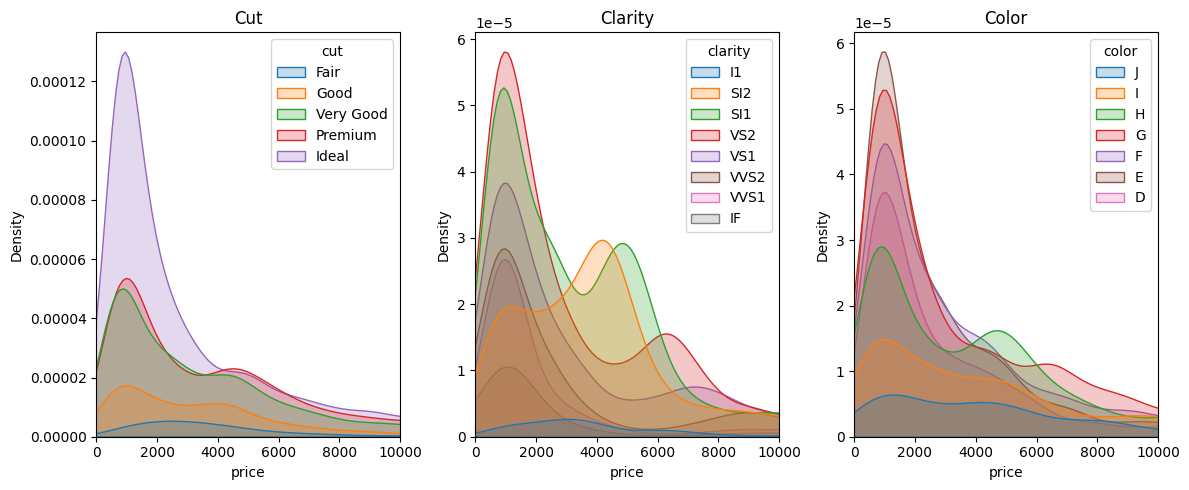

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.kdeplot(data=df, x="price", hue="cut", shade=True, ax=axes[0])
axes[0].set_xlim(0, 10000)
axes[0].set_title("Cut")

sns.kdeplot(data=df, x="price", hue="clarity", shade=True, ax=axes[1])
axes[1].set_xlim(0, 10000)
axes[1].set_title("Clarity")

sns.kdeplot(data=df, x="price", hue="color", shade=True, ax=axes[2])
axes[2].set_xlim(0, 10000)
axes[2].set_title("Color")

plt.tight_layout()
plt.show();

<Axes: xlabel='price'>

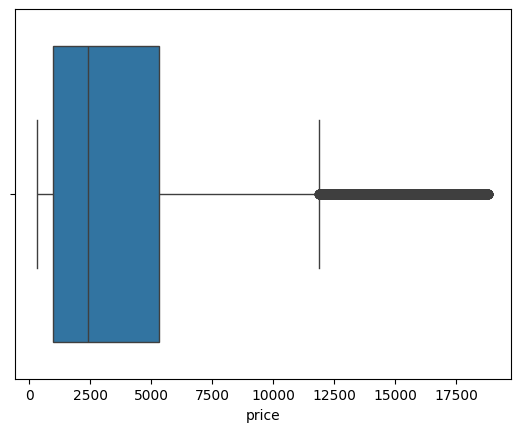

In [46]:
#boxplot
sns.boxplot(x=df["price"])

<Axes: xlabel='color', ylabel='price'>

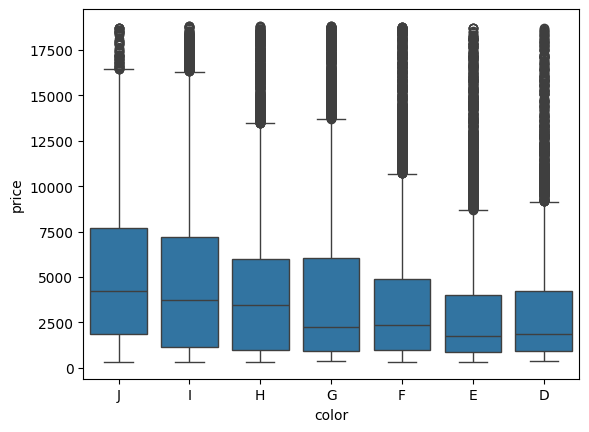

In [47]:
sns.boxplot(x="color", y="price", data=df)

<Axes: xlabel='color', ylabel='price'>

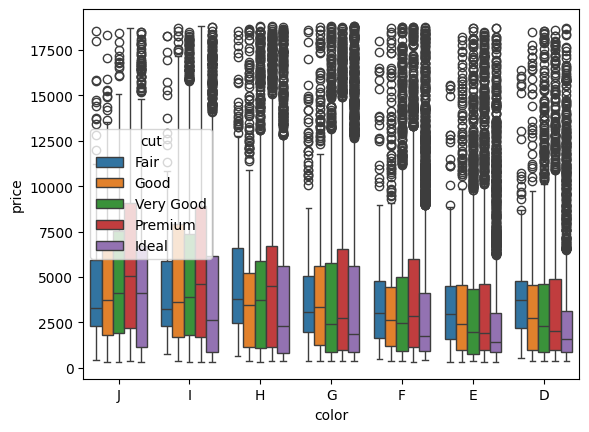

In [48]:
sns.boxplot(x="color", y="price", hue="cut", data=df)

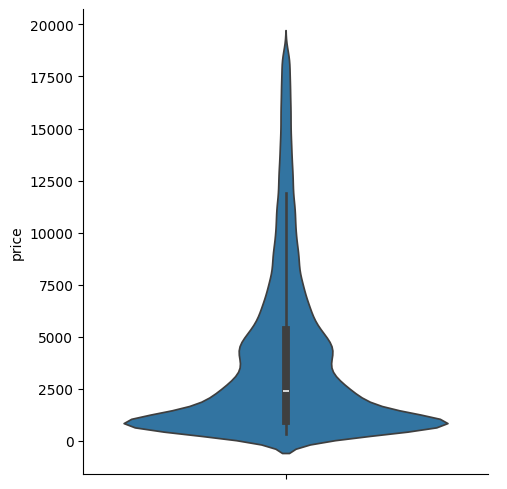

In [49]:
#violin
sns.catplot(y="price", kind="violin", data=df)

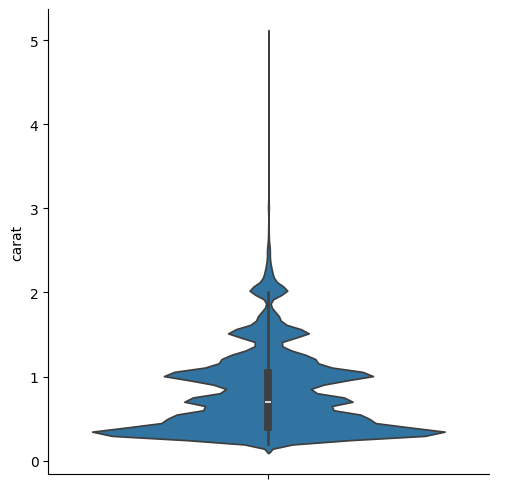

In [50]:
sns.catplot(y="carat", kind="violin", data=df)

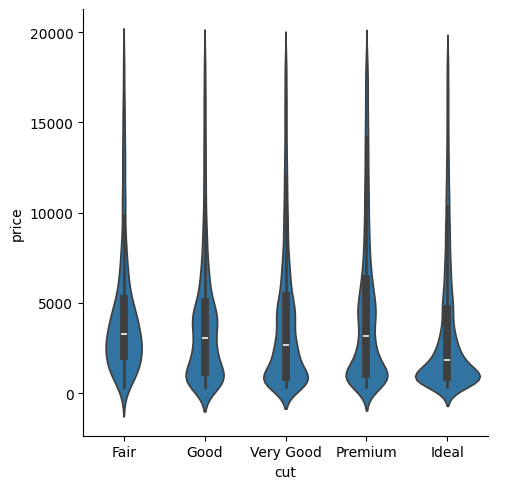

In [51]:
sns.catplot(x="cut",y="price", kind="violin", data=df)

In [52]:
# Correlation graphs

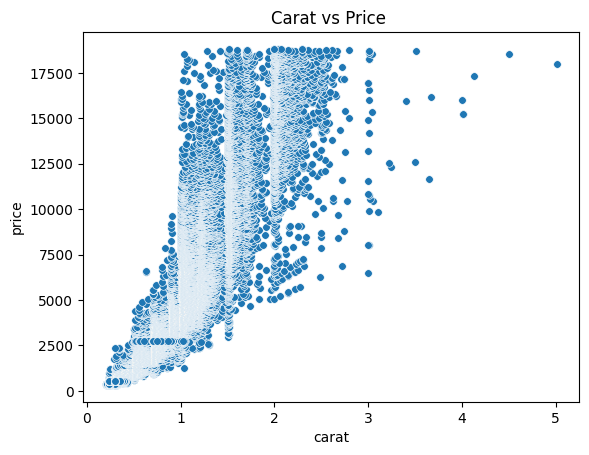

In [53]:
# Scatter plot
sns.scatterplot(x="carat", y="price", data=df,s=30)
plt.title("Carat vs Price ")
plt.show()

<Axes: xlabel='carat', ylabel='price'>

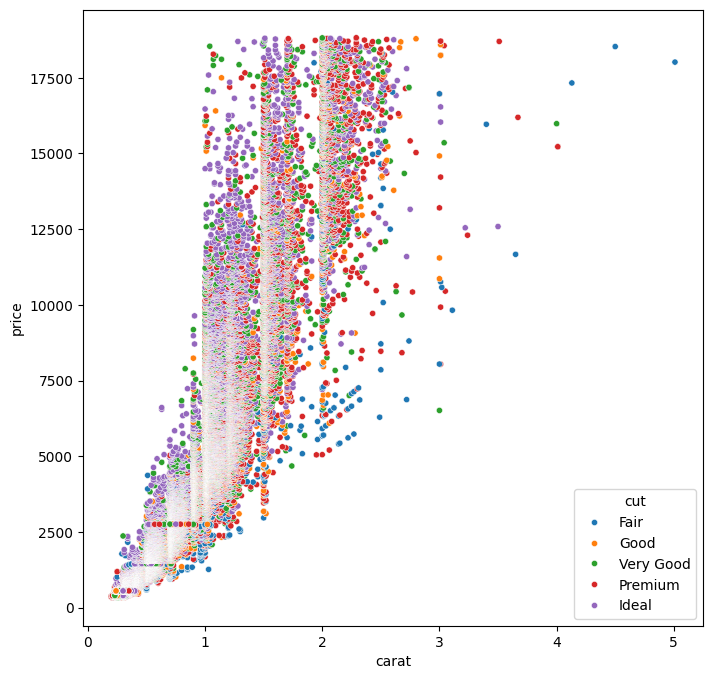

In [54]:
plt.figure(figsize=(8,8))
sns.scatterplot(x="carat", y="price", hue="cut", data=df,s=20)

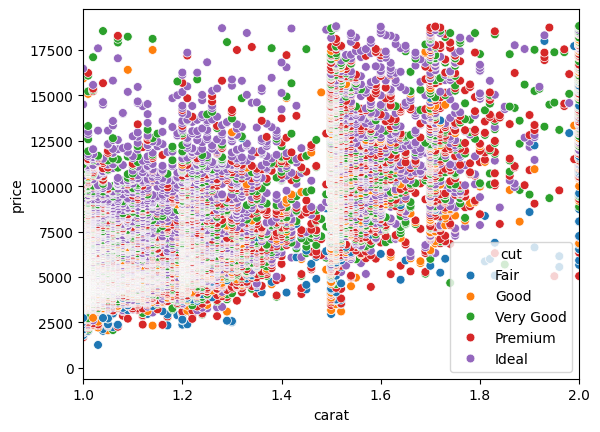

In [55]:
sns.scatterplot(x="carat", y="price", hue="cut", data=df, s=40)
plt.xlim(1,2)
plt.show()

<Axes: xlabel='carat', ylabel='price'>

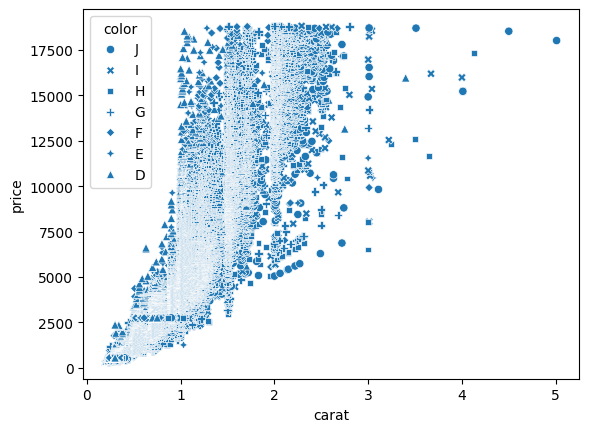

In [56]:
sns.scatterplot(x="carat", y="price",style="color", data=df)

<Axes: xlabel='carat', ylabel='price'>

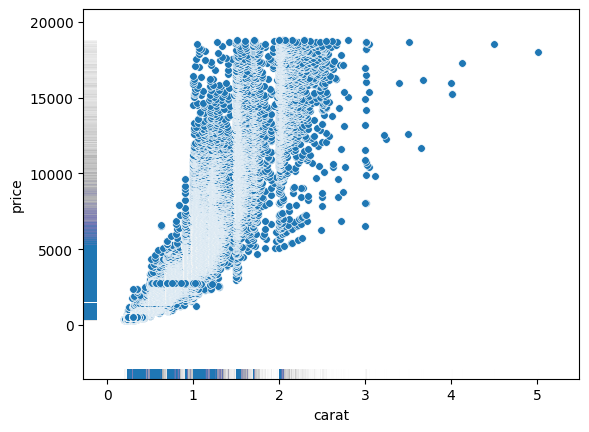

In [57]:
sns.scatterplot(data=df, x="carat", y="price", s=30)
sns.rugplot(data=df, x="carat", y="price", lw=1, alpha=.005)

In [58]:
#lmplot

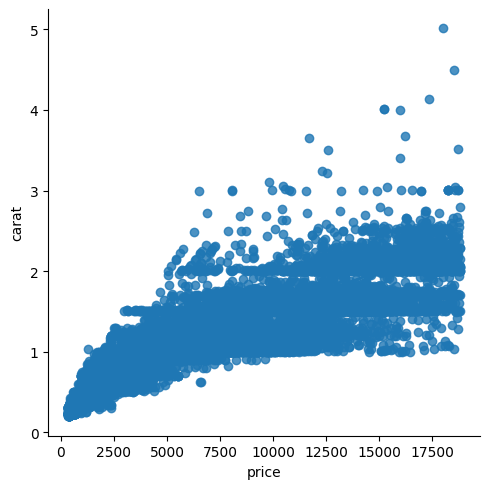

In [59]:
sns.lmplot( x="price", y="carat", data=df)

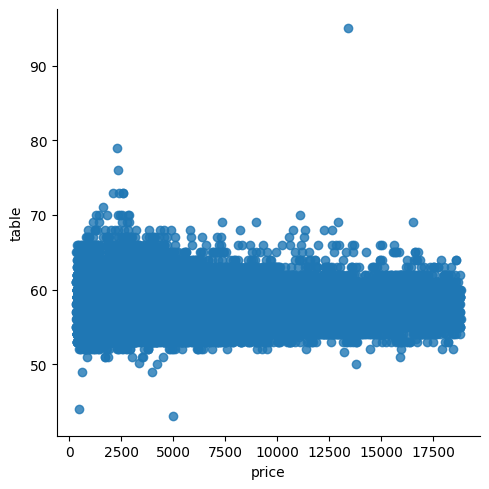

In [60]:
sns.lmplot( x="price", y="table", data=df)

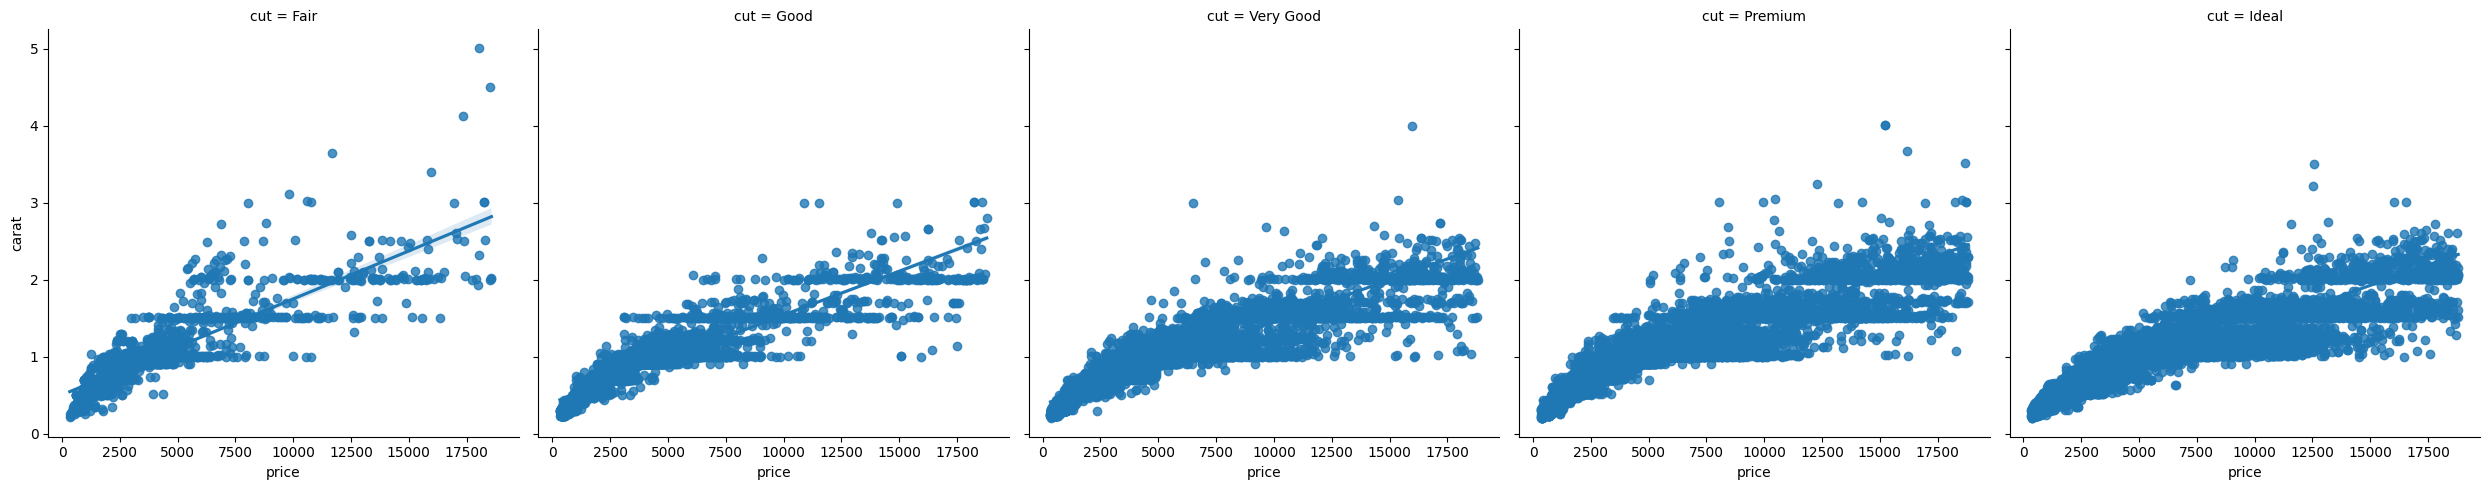

In [61]:
sns.lmplot( x="price", y="carat", col="cut", data=df)

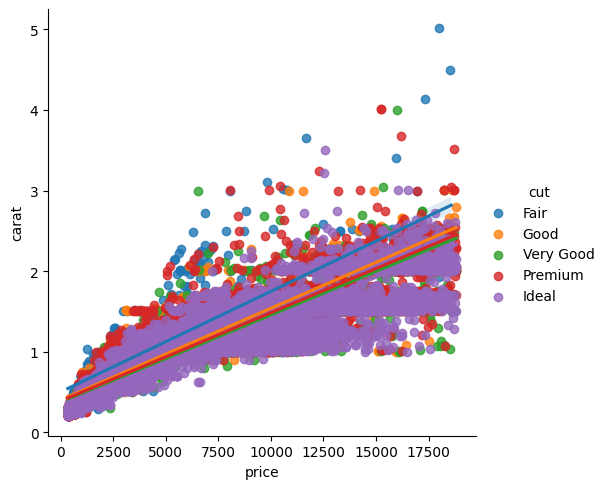

In [62]:
sns.lmplot( x="price", y="carat", hue="cut" ,data=df)

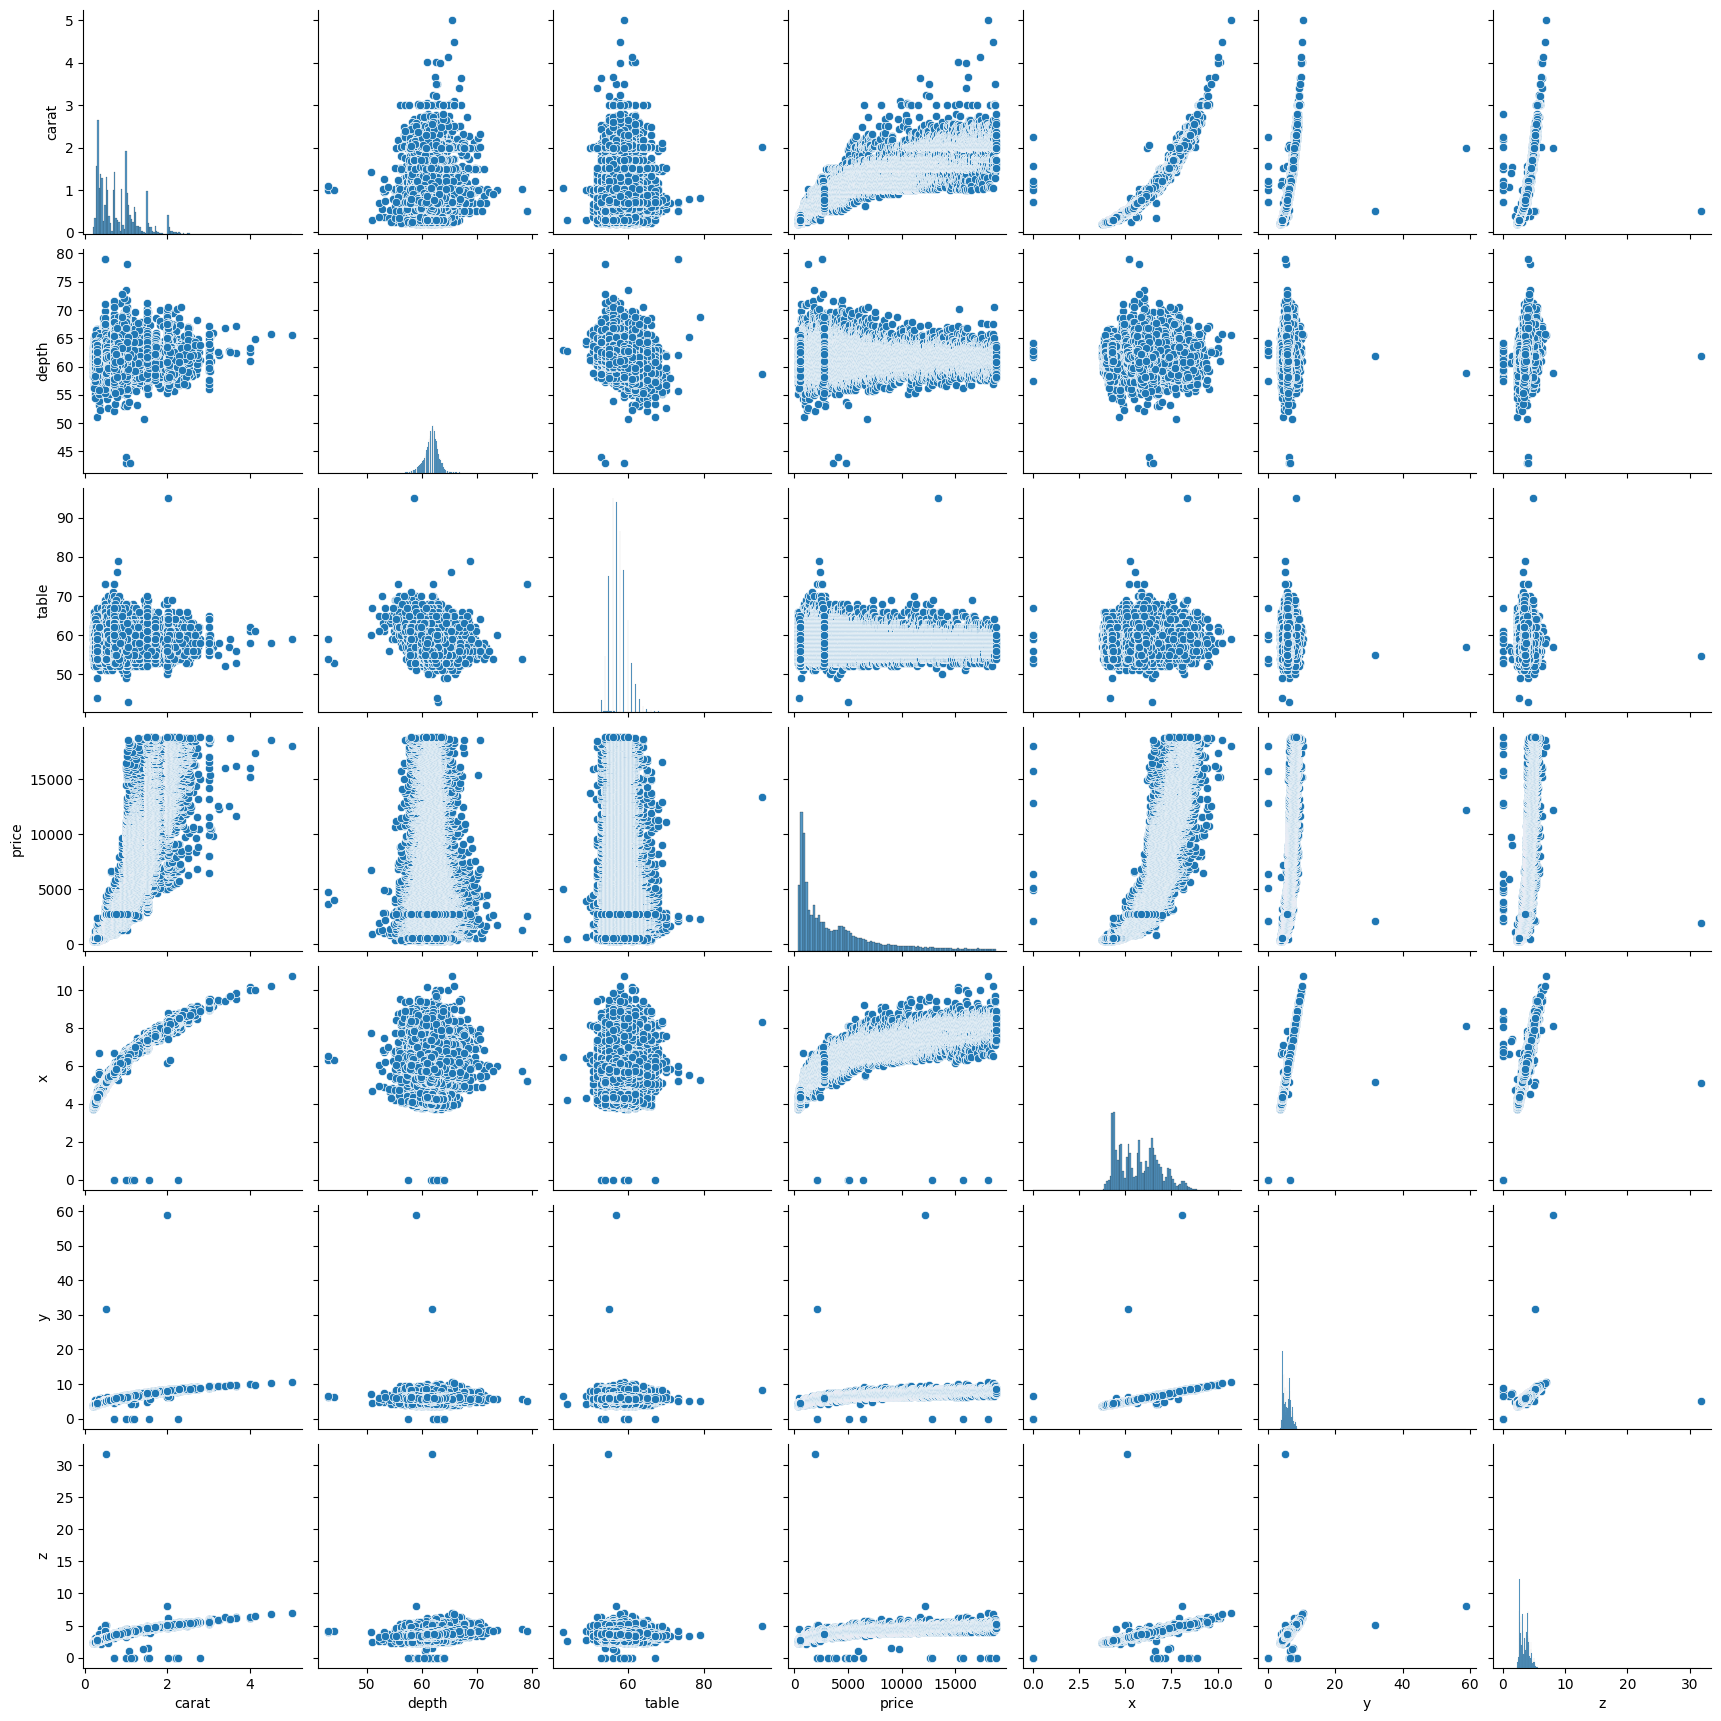

In [63]:
sns.pairplot(df)
# matrix chart showing relationships between all numerical variables in a data set
# If there is no structural form in scatterplot graphs, it means that there is no relationship between two variables.
# If the observation points in the graph are clustered in different corners, crossover cases should be examined.

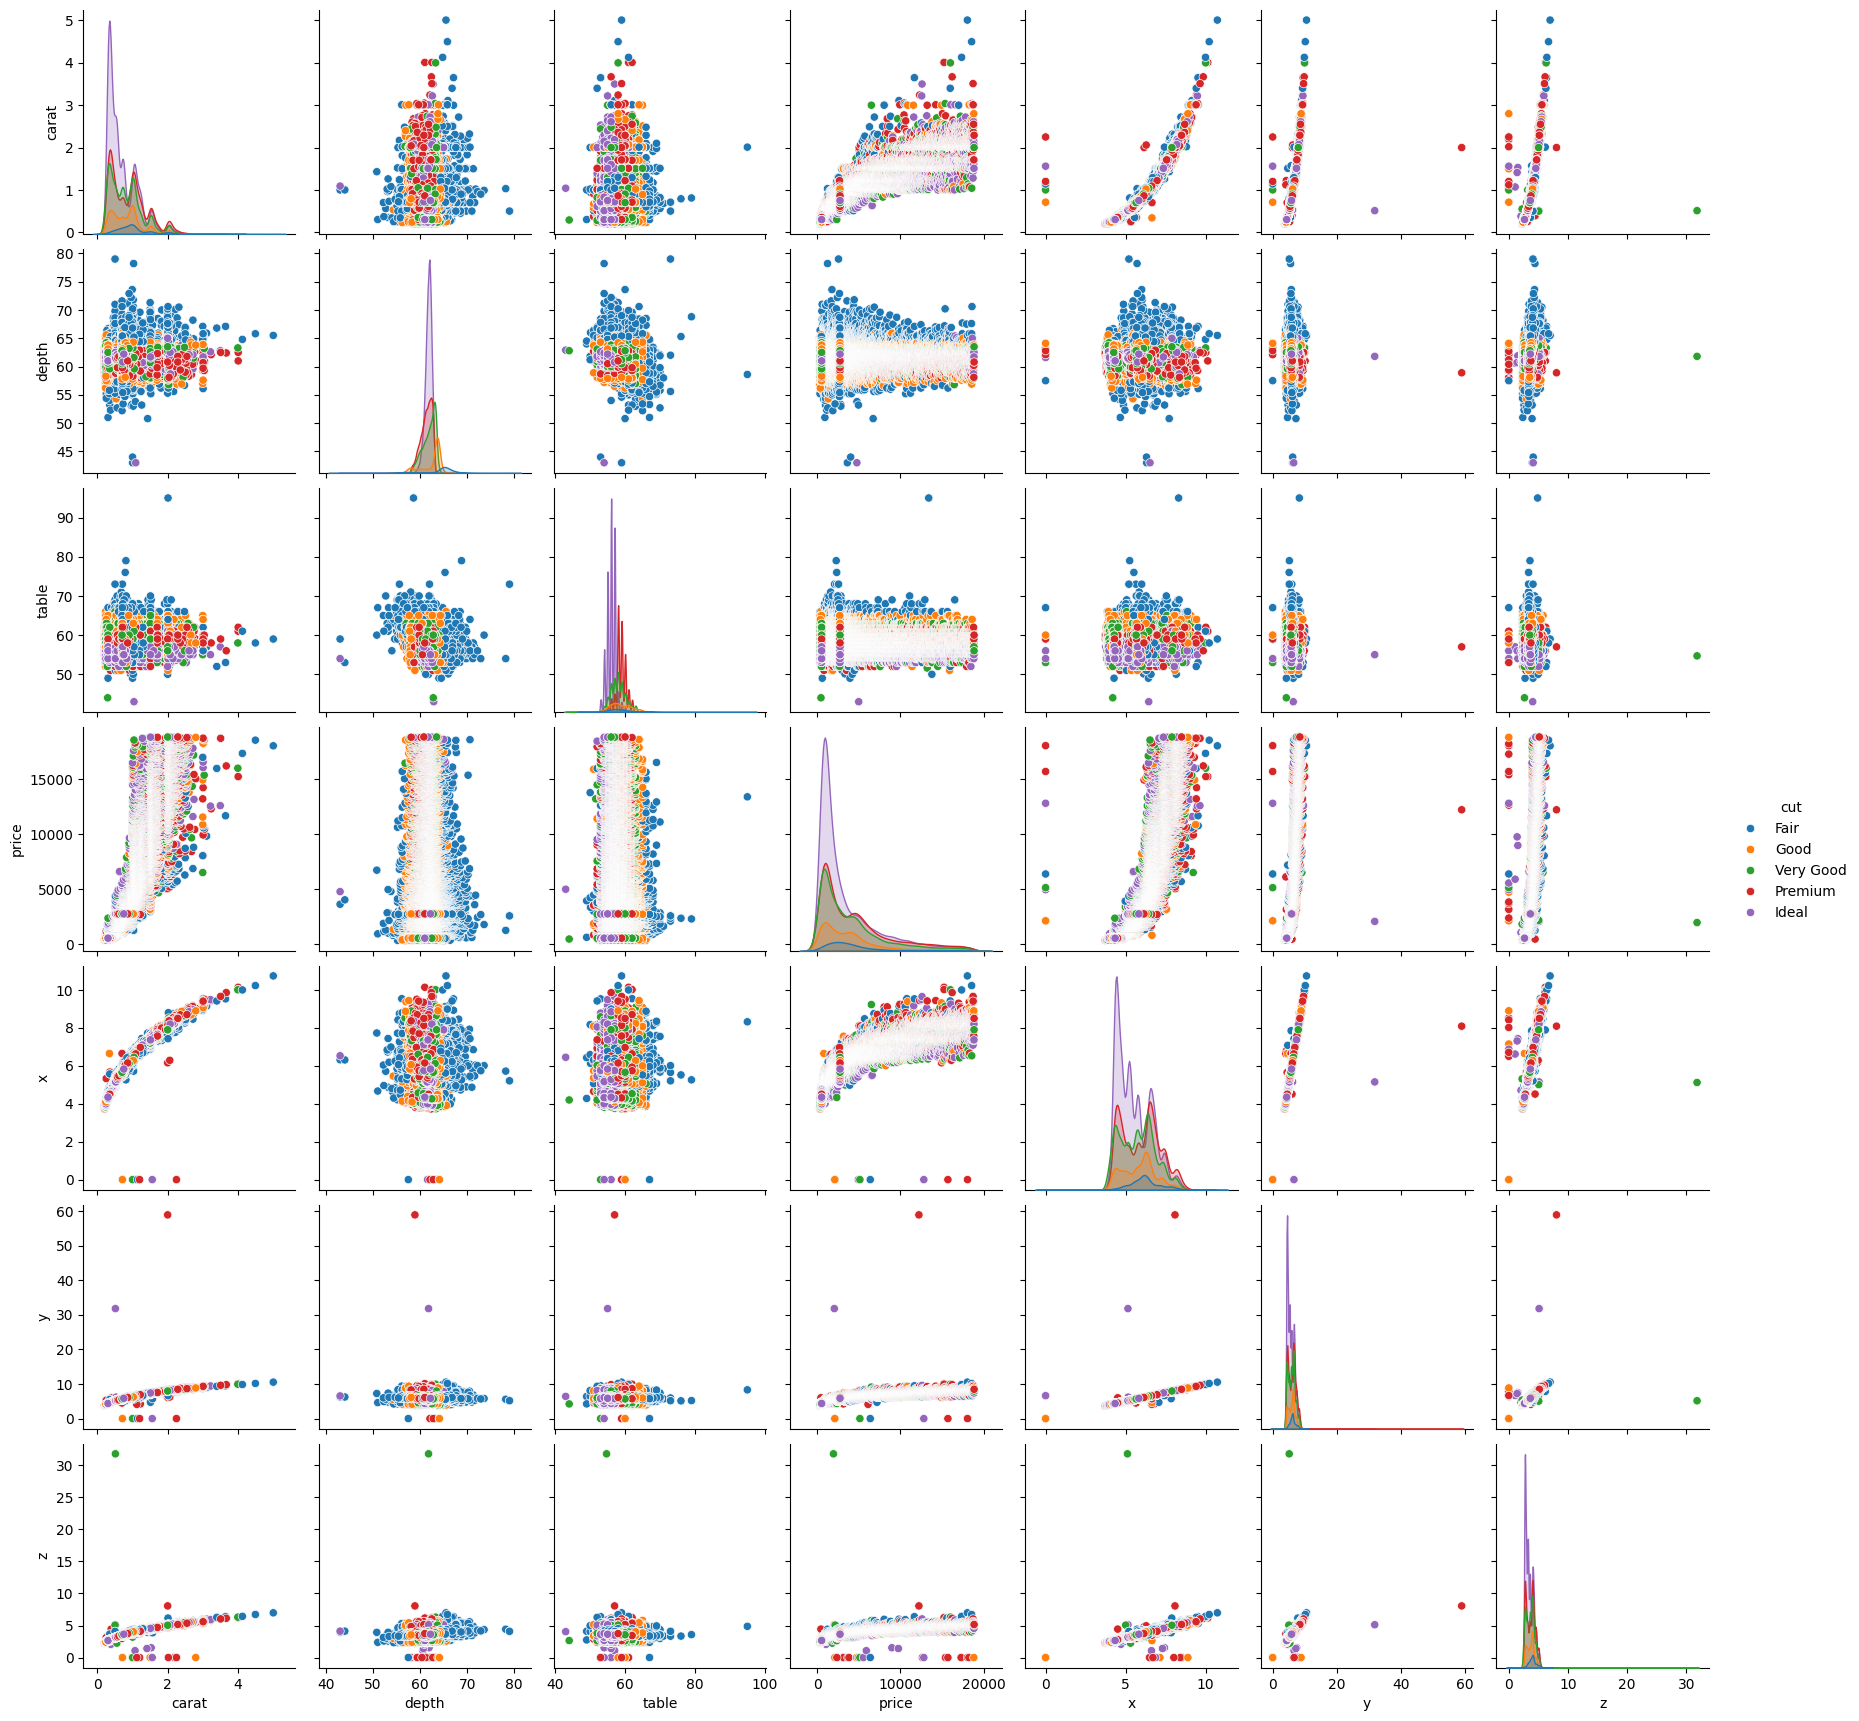

In [64]:
sns.pairplot(df, hue="cut")